In [141]:
import pandas as pd
import ast
from collections import Counter
import re
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px

In [142]:
hotels = pd.read_csv('hotels.csv')
hotels.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [143]:
# Заполним пропуски
hotels = hotels.fillna(0)

In [144]:
# 4.2 Сколько всего отелей в наборе данных
hotels['hotel_name'].nunique()

1492

In [145]:
# 4.3 Когда был оставлен самый свежий отзыв?
# Приводим столбец к формату date
hotels['review_date'] = pd.to_datetime(hotels['review_date'], errors='coerce')

earliest_date = hotels['review_date'].min()
print(earliest_date)

# Дата самого позднего отзыва
latest_date = hotels['review_date'].max()
print(latest_date)

2015-08-04 00:00:00
2017-08-03 00:00:00


In [146]:
# 4.4 Сколько уникальных тегов представлено в наборе данных?

#Инициализируем функицию для преобразования строк в список тегов
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []  # если не удалось распарсить, вернём пустой список

# Преобразуем строки в списки тегов
hotels["tags"] = hotels["tags"].apply(safe_eval)

# Собираем все теги
all_tags = [tag.strip() for tags in hotels["tags"] for tag in tags]

# Убираем возможные пустые строки и лишние пробелы
all_tags = [tag for tag in all_tags if tag]

# Находим уникальные
unique_tags = set(all_tags)

print(f"Количество уникальных тегов: {len(unique_tags)}")
print("Примеры тегов:", list(unique_tags)[:10])

Количество уникальных тегов: 2368
Примеры тегов: ['Deluxe Club Double Room', 'Triple Room Luxury XXL King Size Bed', 'Standard Twin Room with Sofa', 'Double without credit card', 'Junior Suite with Canal View', 'Two Adjoining Superior Suite', 'Family Room 4 guest', 'Classic Double Room with Courtyard View', 'Premium Family Room', 'Large Penthouse Suite with Terrace and City View']


In [ ]:
# 4.5 Какой тег представлен в наибольшем числе отзывов?

tag_counts = Counter(all_tags)

# Находим самый частый тег
most_common_tag, count = tag_counts.most_common(1)[0]

print(f"Самый часто встречающийся тег: '{most_common_tag}'")
print(f"Он встречается в {count} отзывах")

Самый часто встречающийся тег: 'Leisure trip'
Он встречается в 313593 отзывах


In [ ]:
# 4.6 Из тегов выясните, на сколько ночей чаще всего останавливаются путешественники в отелях.

# Отбираем теги, где есть слово "night"
nights_tags = [tag for tag in all_tags if 'night' in tag.lower()]

# Извлекаем число ночей из каждого тега
# Инициализируем список
nights = []
for tag in nights_tags:
    match = re.search(r"(\d+)\s*night", tag.lower())
    if match:
        nights.append(int(match.group(1)))
        
# Считаем сколько раз встречается каждое количество ночей
nights_count = Counter(nights)

# Находим самое популярное значение
most_common_night, count = nights_count.most_common(1)[0]
        
print(f'Чаще всего путешественники останавливаются на {most_common_night} ночей')

Чаще всего путешественники останавливаются на 1 ночей


Text(0, 0.5, 'Количество гостей')

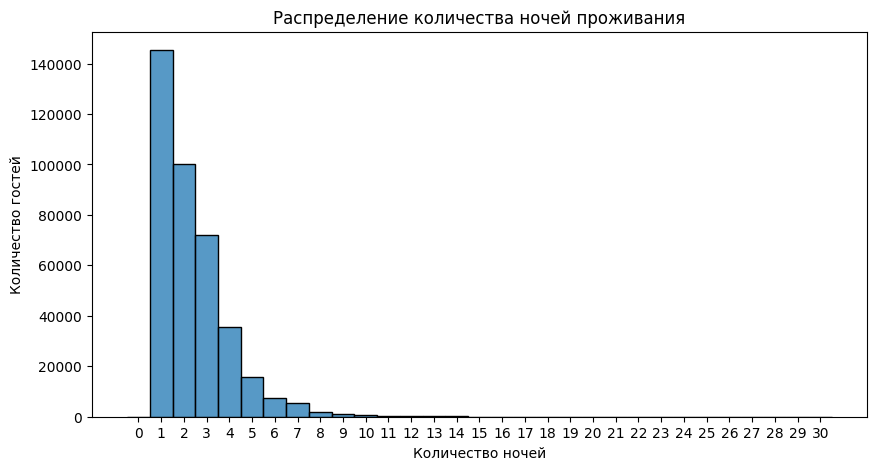

In [149]:
# Мы посчитали наиболее частое количество ночей, теперь посчитаем количесвто ночей для каждого тега
# Инициализируем функцию, куда подаем на вход список тегов
def extract_nights(all_tags):
    # Для каждого тега в списке тегов
    for tag in all_tags:
        # Берем переменную, в которую записываем результат поиска по шаблону, где Stayed - часть текста с пробелом, (\d+) - запоминаем число или несколько чисел от 0 до 9
        match = re.search(r"Stayed (\d+) night", tag)
        # Если нашел совпадения
        if match:
            # Берем первое пойманное выражение в скобках
            return int(match.group(1))
    # Если нет совпадений - None
    return None

# Создаем признак с количеством ночей путем применения к столбцу вышенаписанной функции
hotels['stay_length'] = hotels['tags'].apply(extract_nights)
# Зададим переменную максимального количества ночей для бинов
max_nights = int(hotels['stay_length'].max())
# Задаем бины от -0.5 для корректного отображения столбцов
bins = [i - 0.5 for i in range(0, max_nights + 2)]

# Строим фигуру
plt.figure(figsize=(10,5))
sns.histplot(
    data=hotels,
    x='stay_length',
    bins=bins
)

# Делаем тики по целым числам, чтобы видеть каждое уникальное число ночей
plt.xticks(
    ticks=range(0, max_nights + 1)
)

# Подписи и заголовок
plt.title("Распределение количества ночей проживания")
plt.xlabel("Количество ночей")
plt.ylabel("Количество гостей")

Чаще всего в отеле оставались на 1 ночь

Text(0, 0.5, 'Количество отзывов')

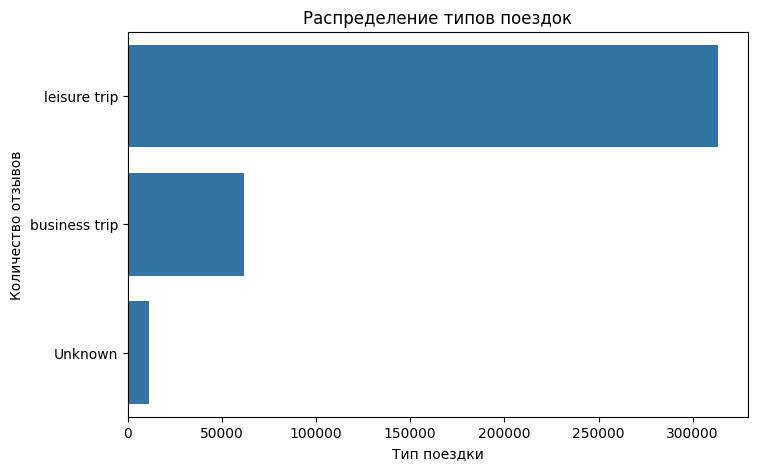

In [ ]:
# Введем еще один признак trip_type
# Инициализируем функцию для сортировки типов поездок, в ней приводим теги к нижнему регистру и проходимся
# по всем тегам, если встречаем совпадение - его и возвращаем, также возвращаем Unknown, если тип не определен
def search_trip_type(all_tags):
    for tag in all_tags:
        tag_lower = tag.lower()
        if 'business trip' in tag_lower:
            return 'business trip'
        if 'leisure trip' in tag_lower:
            return 'leisure trip'
    
    return 'Unknown'

# Создаем признак
hotels['trip_type'] = hotels['tags'].apply(search_trip_type)

# Создадим фигуру
plt.figure(figsize=(8, 5))

sns.countplot(
    data=hotels,
    y='trip_type'
)

# Подпишем график
plt.title("Распределение типов поездок")
plt.xlabel("Тип поездки")
plt.ylabel("Количество отзывов")

Подавляющее большинство гостей отелей оставались во время отдыха\отпуска

In [151]:
# Введем еще признак сезонности
# Создадим признак месяца
hotels['review_month'] = hotels['review_date'].dt.month

# Инициализируем функицю определения сезона
def get_season(month):
    if month in [12,1,2]:
        return "winter"
    if month in [3,4,5]:
        return "spring"
    if month in [6,7,8]:
        return "summer"
    return "autumn"

# Создадим признак сезонности, применив функцию к столбцу с месяцем
hotels['season'] = hotels['review_month'].apply(get_season)

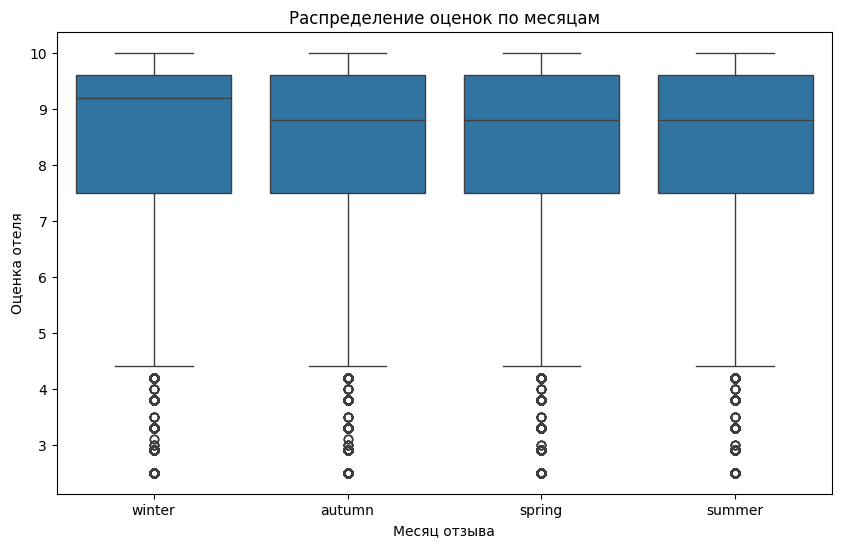

In [152]:
# Теперь построим коробчатую диаграмму с рейтингом отелей по сезонам
plt.figure(figsize=(10,6))
sns.boxplot(data=hotels, x='season', y='reviewer_score')
plt.title('Распределение оценок по месяцам')
plt.xlabel('Месяц отзыва')
plt.ylabel('Оценка отеля')
plt.show()

Как видно из графика, зимой больше всего положительных отзывов

In [ ]:
# Удаляем ненужные столбцы
hotels = hotels.drop(['hotel_address', 'hotel_name', 'review_date', 'negative_review', 'positive_review', 'tags',], axis=1)

In [ ]:
# Преобразуем признак в числовой
hotels['days_since_review'] = hotels['days_since_review'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Кирилл\AppData\Local\Temp\ipykernel_12132\4002991393.py:1: SyntaxWarning: invalid escape sequence '\d'
  hotels['days_since_review'] = hotels['days_since_review'].str.extract('(\d+)').astype(int)


In [ ]:
# Кодируем reviewer_nationality — frequency encoding
freq_encoding = hotels['reviewer_nationality'].value_counts(normalize=True)
hotels['reviewer_nationality_enc'] = hotels['reviewer_nationality'].map(freq_encoding)

# Кодируем trip_type — one-hot
hotels = pd.get_dummies(hotels, columns=['trip_type'], drop_first=True)

# Кодируем season — label encoding
season_map = {'winter': 0, 'spring': 1, 'summer': 2, 'autumn': 3}
hotels['season_enc'] = hotels['season'].map(season_map)

# Удаляем исходные столбцы
hotels = hotels.drop(['reviewer_nationality', 'season', 'review_month'], axis=1)


In [ ]:
# Числовые признаки
num_cols = ['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'days_since_review', 'lat', 'ing', 'stay_length', 'eview_month']

# категориальные признаки
cat_cols = ['reviewer_nationality', 'trip_type', 'season']

In [157]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

In [158]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [159]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [161]:
# Импортируем необходимые библиотеки: 
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  


In [162]:
print(X.columns.tolist())

['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'days_since_review', 'lat', 'lng', 'stay_length', 'reviewer_nationality_enc', 'trip_type_business trip', 'trip_type_leisure trip', 'season_enc']


<Axes: title={'center': 'Значимость признаков (f_regression)'}>

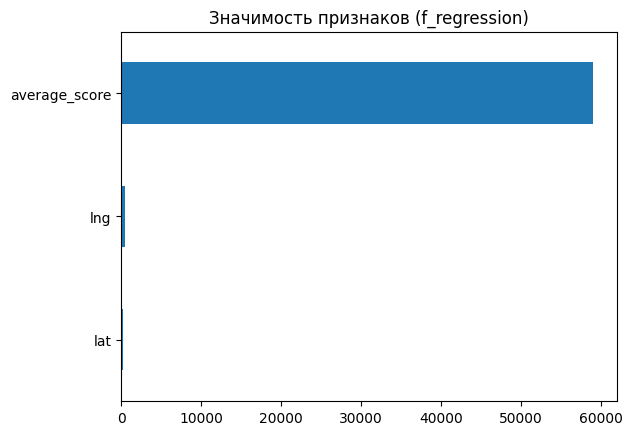

In [163]:
# --- Анализ значимости признаков при регрессии ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import f_regression
import pandas as pd

# Категориальные (числовые) признаки
cat_cols = ['average_score', 'lat', 'lng']

# Разделяем признаки и целевую переменную
X = hotels.drop(['reviewer_score'], axis=1)
y = hotels['reviewer_score']

# Масштабируем признаки в диапазон [0, 1] (не обязательно, но полезно)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X[cat_cols]), columns=cat_cols)

# Вычисляем важность признаков через f_regression
imp_cat = pd.Series(f_regression(X_scaled, y)[0], index=cat_cols)

# Сортируем и строим график
imp_cat.sort_values(inplace=True)
imp_cat.plot(kind='barh', title='Значимость признаков (f_regression)')

In [164]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13578982920337146


Как видно значение метрики снизилось до 0.1357

Можно еще отдельно посчитать количество слов в позитивных и негативных отзывах

Сравнить рейтинг в отзывах по типу поездок 